## Focal Length Calibration

For each ZL034 and ZR034 we will find a model of the focal length $fl$ as a function of focus motor-count $fmc$. The model would be a simple line, given as 

$$fl(fmc) = \alpha_{fl} + \beta_{fl} \cdot fmc$$

Let $D_{fl-fmc,ZL34}=\left\{(fl_{l,0}, fmc_{l,0}), (fl_{l,1}, fmc_{l,1}), \dots, (fl_{l,n}, fmc_{l,n})\right\}$ be the set of zcam left 34mm focal length and focus motor count pairs and let $D_{fl-fmc,ZR34}=\left\{(fl_{r,0}, fmc_{r,0}), (fl_{r,1}, fmc_{r,1}), \dots, (fl_{r,n}, fmc_{r,n})\right\}$ be the corresponding dataset of the right zcam. 

Need to solve 

$$\min_{\alpha_l, \beta_l} \sum_{i=0}^n ( (\beta_l \cdot fmc_i +  \alpha_l) - fl_i)^2$$
for $\alpha_l, \beta_l$. 

To do so, we utilize the normal equation 

$$\theta_l = (X_l^TX_l)^{-1}X_l^TY_l$$
where 
\begin{align*}
  \theta=\begin{bmatrix}\beta_l\\\alpha_l\end{bmatrix} &&
  X_l = \begin{bmatrix}fmc_{l,0}&&1\\fmc_{l,1}&&1\\ \vdots&&1 \\fmc_{l,n}&&1\end{bmatrix} &&
  Y_l = \begin{bmatrix}fl_{l,0}\\fl_{l,1}\\\vdots\\fl_{l,n}\end{bmatrix}
\end{align*}

where the inverse we use would be the penrose pseudo-inverse. 


Similarly for the right cameras, 
$$\alpha_r, \beta_r = \arg\min_{\alpha_r, \beta_r} \sum_{i=0}^n ( (\beta_r \cdot fmc_i +  \alpha_r) - fl_i)^2$$

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None  # default='warn'


data_fpath = "data/m41_site_cal_v227_v8_processed.xlsx"
data = pd.read_excel(data_fpath)

zl34 = data[data["cam"] == "ZL034"].copy()
zr34 = data[data["cam"] == "ZR034"].copy()

print(f"Number of data points for zl034:{zl34.shape[0]}")
print(f"Number of data points for zr034:{zr34.shape[0]}")

Number of data points for zl034:344
Number of data points for zr034:323


X_l shape:(344, 2); Y_l shape:(344,); theta_l:[5.01639695e-02 4.68209789e+03]; MSE_l:101.042097
X_r shape:(323, 2); Y_r shape:(323,); theta_r:[5.31455367e-02 4.68747381e+03]; MSE_r:143.618222


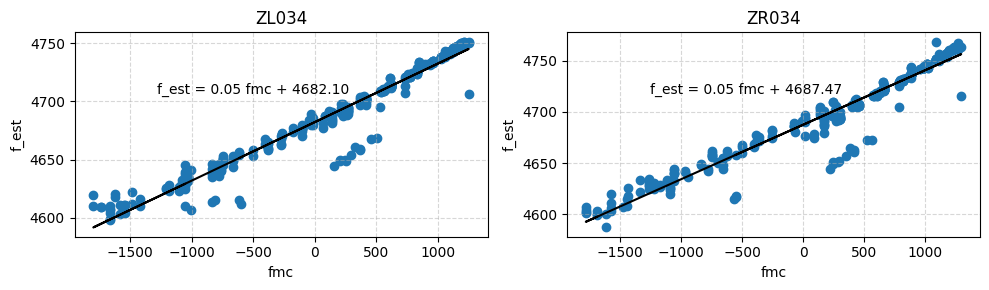

In [48]:
## solve for an approx BFL to identfy outliers

# solve for theta_left
X_l = np.vstack([zl34["fmc"], np.ones(zl34.shape[0])]).T
Y_l = zl34["f_est"]
theta_l = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ Y_l
residual_l = ((Y_l - X_l @ theta_l).T @ (Y_l - X_l @ theta_l))/X_l.shape[0]

print(f"X_l shape:{X_l.shape}; Y_l shape:{Y_l.shape}; theta_l:{theta_l}; MSE_l:{residual_l:0.6f}")

# solve for theta_right
X_r = np.vstack([zr34["fmc"], np.ones(zr34.shape[0])]).T
Y_r = zr34["f_est"]
theta_r = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ Y_r
residual_r = ((Y_r - X_r @ theta_r).T @ (Y_r - X_r @ theta_r))/X_r.shape[0]

print(f"X_r shape:{X_r.shape}; Y_r shape:{Y_r.shape}; theta_r:{theta_r}; MSE_r:{residual_r:0.6f}")

# plot Y_l as a funciton of X_l with the line of best fit
fig, ax = plt.subplots(1, 2, figsize=(10,3))

# left focal-length as a function of fmc
ax[0].scatter(zl34["fmc"], zl34["f_est"], label="f_est")
ax[0].plot(zl34["fmc"], X_l @ theta_l, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_l), color="black")
ax[0].set_xlabel("fmc")
ax[0].set_ylabel("f_est")
ax[0].set_title("ZL034")
ax[0].grid(linestyle="--", alpha=0.5)
ax[0].text(0.2, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_l), transform=ax[0].transAxes)


# right focal-length as a function of fmc
ax[1].scatter(zr34["fmc"], zr34["f_est"], label="f_est")
ax[1].plot(zr34["fmc"], X_r @ theta_r, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_r), color="black")
ax[1].set_xlabel("fmc")
ax[1].set_ylabel("f_est")
ax[1].set_title("ZR034")
ax[1].grid(linestyle="--", alpha=0.5)
ax[1].text(0.2, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_r), transform=ax[1].transAxes)


plt.tight_layout()
plt.show()

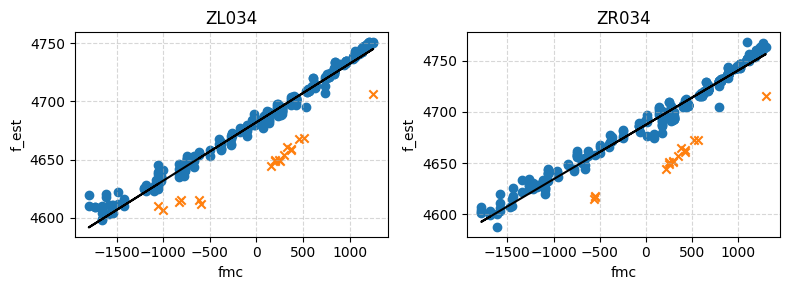

In [49]:
# Here we manually identify the outliers


# identify the outliers
zl34["residual"] = (zl34["f_est"] - (X_l @ theta_l))
zr34["residual"] = (zr34["f_est"] - (X_r @ theta_r))
# print(f"Left outlier idx:{zl34['residual'].abs() > 18}")
# print(f"right outlier idx:{zr34['residual'].abs() > 18}")
      
left_outlier_idx = [2, 34, 35, 36, 37, 38, 39, 41, 48, 54, 215, 549, 917, 1083, 1096, 1101, 1113, 1122, 1793, 2610, 2620]
right_outlier_idx = [218, 219, 253, 254, 255, 256, 257, 258, 260, 267, 273, 788, 815, 942, 1203, 1758, 2658]
left_cfm_outlier_idx = [2, 34, 35, 36, 37, 38, 39, 41, 48, 54, 215, 549, 917, 1083, 1096, 1113, 1122, 1793]
right_cfm_outlier_idx = [218, 219, 253, 254, 255, 256, 257, 258, 260, 267, 273, 788, 815, 942, 2658]

zl34["outlier"] = zl34.index.isin(left_cfm_outlier_idx)
zr34["outlier"] = zr34.index.isin(right_cfm_outlier_idx)


# plot the points that are not outliers and those that are outliers on the same plot with different markers
fig, ax = plt.subplots(1, 2, figsize=(8,3))

# left focal-length as a function of fmc
ax[0].scatter(zl34[~zl34["outlier"]]["fmc"], zl34[~zl34["outlier"]]["f_est"], label="f_est", marker="o")
ax[0].scatter(zl34[zl34["outlier"]]["fmc"], zl34[zl34["outlier"]]["f_est"], label="outlier", marker="x")
# ax[0].scatter(zl34.loc[left_outlier_idx]["fmc"], zl34.loc[left_outlier_idx]["f_est"], label="outlier", marker="x", color="orange")
# ax[0].scatter(zl34.loc[left_cfm_outlier_idx]["fmc"], zl34.loc[left_cfm_outlier_idx]["f_est"], label="outlier", marker="x", color="black")
ax[0].plot(zl34["fmc"], X_l @ theta_l, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_l), color="black")
ax[0].set_xlabel("fmc")
ax[0].set_ylabel("f_est")
ax[0].set_title("ZL034")
ax[0].grid(linestyle="--", alpha=0.5)

# right focal-length as a function of fmc
ax[1].scatter(zr34[~zr34["outlier"]]["fmc"], zr34[~zr34["outlier"]]["f_est"], label="f_est", marker="o")
ax[1].scatter(zr34[zr34["outlier"]]["fmc"], zr34[zr34["outlier"]]["f_est"], label="outlier", marker="x")
# ax[1].scatter(zr34.loc[right_outlier_idx]["fmc"], zr34.loc[right_outlier_idx]["f_est"], label="outlier", marker="x")
# ax[1].scatter(zr34.loc[right_cfm_outlier_idx]["fmc"], zr34.loc[right_cfm_outlier_idx]["f_est"], label="outlier", marker="x", color="black")

ax[1].plot(zr34["fmc"], X_r @ theta_r, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_r), color="black")
ax[1].set_xlabel("fmc")
ax[1].set_ylabel("f_est")
ax[1].set_title("ZR034")
ax[1].grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

alpha_l:4684.257100; beta_l:0.0497613; MSE_l:21.148778
alpha_r:4689.772199; beta_r:0.053044; MSE_r:38.618437


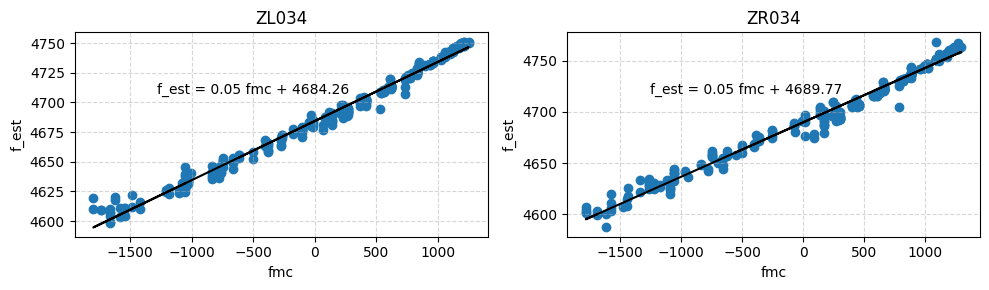

In [50]:
# Here we perform the same fit without the outliers

# outliers we identified above; copying code so we dont have to run above cell
left_cfm_outlier_idx = [2, 34, 35, 36, 37, 38, 39, 41, 48, 54, 215, 549, 917, 1083, 1096, 1113, 1122, 1793]
right_cfm_outlier_idx = [218, 219, 253, 254, 255, 256, 257, 258, 260, 267, 273, 788, 815, 942, 2658]
zl34["outlier"] = zl34.index.isin(left_cfm_outlier_idx)
zr34["outlier"] = zr34.index.isin(right_cfm_outlier_idx)

# perform the same fit without the outliers
X_l = np.vstack([zl34[~zl34["outlier"]]["fmc"], np.ones(zl34[~zl34["outlier"]].shape[0])]).T
Y_l = zl34[~zl34["outlier"]]["f_est"]
theta_l = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ Y_l
residual_l = ((Y_l - X_l @ theta_l).T @ (Y_l - X_l @ theta_l))/X_l.shape[0]

X_r = np.vstack([zr34[~zr34["outlier"]]["fmc"], np.ones(zr34[~zr34["outlier"]].shape[0])]).T
Y_r = zr34[~zr34["outlier"]]["f_est"]
theta_r = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ Y_r
residual_r = ((Y_r - X_r @ theta_r).T @ (Y_r - X_r @ theta_r))/X_r.shape[0]

print(f"alpha_l:{theta_l[1]:.6f}; beta_l:{theta_l[0]:.6}; MSE_l:{residual_l:0.6f}")
print(f"alpha_r:{theta_r[1]:.6f}; beta_r:{theta_r[0]:.6}; MSE_r:{residual_r:0.6f}")

# plot the point thar are not outliers and the line of best fit found without the outliers
fig, ax = plt.subplots(1, 2, figsize=(10,3))
# left focal-length as a function of fmc
ax[0].scatter(zl34[~zl34["outlier"]]["fmc"], zl34[~zl34["outlier"]]["f_est"], label="f_est", marker="o")
ax[0].plot(zl34[~zl34["outlier"]]["fmc"], X_l @ theta_l, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_l), color="black")
ax[0].set_xlabel("fmc")
ax[0].set_ylabel("f_est")
ax[0].set_title("ZL034")
ax[0].grid(linestyle="--", alpha=0.5)
ax[0].text(0.2, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_l), transform=ax[0].transAxes)

# right focal-length as a function of fmc
ax[1].scatter(zr34[~zr34["outlier"]]["fmc"], zr34[~zr34["outlier"]]["f_est"], label="f_est", marker="o")
ax[1].plot(zr34[~zr34["outlier"]]["fmc"], X_r @ theta_r, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_r), color="black")
ax[1].set_xlabel("fmc")
ax[1].set_ylabel("f_est")
ax[1].set_title("ZR034")
ax[1].grid(linestyle="--", alpha=0.5)
ax[1].text(0.2, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_r), transform=ax[1].transAxes)

plt.tight_layout()
plt.show()

## Modelling $R_C^M$

Here we want to model the rotation matrix from the mast frame to the camera frame, $R_M^C$. For a given data point $i$, let 
$H^r = \begin{bmatrix}h_i^T\\v_i^T\\a_i^T\end{bmatrix}$. Then $R_C^M$ is related to $H^r$ by the following

$$ H^r =  R_{r'}^r R_M^{r'} R_C^M K^C $$

Now because $R_{r'}^r$ and $R_m^{r'}$ are orthogonal matrices, so 
$(R_{r'}^r)^{-1} = (R_{r'}^r)^T $ and 
$(R_m^{r'})^{-1} = (R_m^{r'})^T$. Observe that $K^c$ is an upper triangular matrix
and there are no zeros on the main diagonal, so it is invertible. The inverse can 
be attained by using backward substitution

$$ (K^c)^{-1} = 
\begin{bmatrix} 
  \frac{1}{f+b_1} & -\frac{b_2}{f(f+b_1)} & \frac{c_yb_2}{f(f+b_1)}-\frac{c_x}{f+b_1}\\
  0 & \frac{1}{f} & -\frac{c_y}{f}\\
  0 & 0 & 1
\end{bmatrix} $$

So we have

$$R_C^M = (R^r_m)^{T} (R_{r'}^r)^T H^r  (K^C)^{-1} \rightarrow q_C^M$$

We model the rotation as a function of focal length, $f$, in terms of quaternions 
$(q_C^{M})' = \alpha + f \cdot \beta$, where $\alpha$ and $\beta$ are quaternions.

The objective function would then be to find $\alpha$ and $\beta$ the solves 

$$ \min_{\alpha, \beta} \sum_{i} \|(q_C^M)'_i - (q_C^M)_i\|^2_2 = \min_{\alpha, \beta} \phi(\alpha, \beta) $$

where $(q_C^M)'_i$ is the quaternion from our linear model and $(q_C^M)_i$ is the quaternion calculated from the data using the above equation. 

Then the jacobian is given as 

$$

\triangledown \phi =
\sum_i
\begin{bmatrix}
  2(\alpha_0 + \beta_0f_i-(q_0)_i)\\
  2(\alpha_1 + \beta_1f_i-(q_1)_i)\\
  2(\alpha_2 + \beta_2f_i-(q_2)_i)\\
  2(\alpha_3 + \beta_3f_i-(q_3)_i)\\
  2(\alpha_0 + \beta_0f_i-(q_0)_i)f_i\\
  2(\alpha_1 + \beta_1f_i-(q_1)_i)f_i\\
  2(\alpha_2 + \beta_2f_i-(q_2)_i)f_i\\
  2(\alpha_3 + \beta_3f_i-(q_3)_i)f_i
\end{bmatrix}
$$


In [2]:
import pandas as pd
import numpy as np
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [3]:
data_path = "data/m41_site_cal_v227_v8.xlsx"


data = pd.read_excel(data_path)
print(f"Number of data points:{data.shape[0]}")

# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# convert strings to vecs/mats
# data["h_r_vec" ] = [to_vec_space(v) for v in data["h_r_est"]]
# data["v_r_vec" ] = [to_vec_space(v) for v in data["v_r_est"]]
# data["a_r_vec" ] = [to_vec_space(v) for v in data["a_r_est"]]
data["h_r_vec" ] = [to_vec_comma(v) for v in data["h_r"]]
data["v_r_vec" ] = [to_vec_comma(v) for v in data["v_r"]]
data["a_r_vec" ] = [to_vec_comma(v) for v in data["a_r"]]
data["R_rpm_mat"] = [to_mat(m) for m in data["R_rpm"]]


Number of data points:3529


In [17]:
left_fl = {"alpha": 4684.257100, "beta": 0.0497613}
right_fl = {"alpha": 4689.772199, "beta": 0.053044}


def get_fl(idx:int, data_:np.ndarray)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl["beta"] * fmc + left_fl["alpha"]
  else:
    return right_fl["beta"] * fmc + right_fl["alpha"]

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_R_rrp(idx: int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r to r_prime frame
  """
  # q_rrp = np.array([0.00035132, -0.0004781 ,  0.00048555, -0.99999971])
  q_rrp = np.array([0, 0 ,  0, 1])
  R_rrp = R.from_quat(q_rrp).as_matrix()
  return R_rrp

def get_R_mc(a0:float, a1:float, a2:float, a3:float,
            b0:float, b1:float, b2:float, b3:float,
            idx:int, data_:np.ndarray)->np.ndarray:
  

  """
  Forms the R_mc matrix where a0...a3 are the constants and b0...b3 are the scalar multiples
  """
  f = data_["fmc"][idx]
  q_mc = np.array([a0+b0*f, a1+b1*f, a2+b2*f, a3+b3*f])
  q_mc = q_mc / np.linalg.norm(q_mc)
  R_mc = R.from_quat(q_mc).as_matrix()

  return R_mc

def get_KC(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1"][idx], data_["b2"][idx], data_["cx"][idx], data_["cy"][idx]
  fl = get_fl(idx, data_)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

# def get_KC_inv(idx:int, data_:np.ndarray)->np.ndarray:
#   b1, b2, cx, cy = data_["b1"][idx], data_["b2"][idx], data_["cx"][idx], data_["cy"][idx]
#   fl = get_fl(idx, data_)
#   kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
#                      [0, 1/fl, -cy/fl],
#                      [0, 0, 1]])
#   return kc_inv

def get_H_r_gt(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=0)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=0)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=0)
  H_i = np.concatenate([h_i, v_i, a_i], axis=0)

  return H_i


Mean ZL034 q_mc:(0.498566, 0.289451, 0.000598, -0.120107)
Mean ZR034 q_mc:(0.512641, 0.290083, 0.018382, -0.106925)


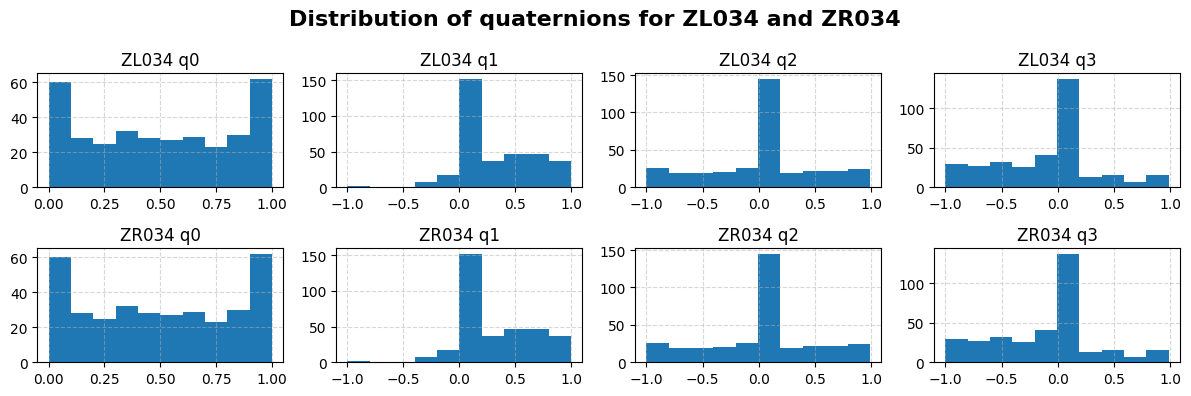

In [24]:
## precompute the quaternions
q0s, q1s, q2s, q3s = [], [], [], []
for i in range(data.shape[0]):
  H_r_gt = get_H_r_gt(i, data)
  Kc = get_KC(i, data)
  R_rrp = get_R_rrp(i, data)
  R_rpm = get_R_rpm(i, data)

  
  R_mc = R_rpm.T  @ R_rrp.T @ H_r_gt @ np.linalg.inv(Kc)
  # R_mc = np.linalg.inv(Kc) @ H_r_gt @ R_rpm @ R_rrp

  rot = R.from_matrix(R_mc)
  q_mc = rot.as_quat()
  if q_mc[0] < 0:
    q_mc = -q_mc
  
  q0s.append(q_mc[0])
  q1s.append(q_mc[1])
  q2s.append(q_mc[2])
  q3s.append(q_mc[3])
  
data["q_mc_0"], data["q_mc_1"], data["q_mc_2"], data["q_mc_3"] = q0s, q1s, q2s, q3s

# finding the mean quaternion for each ZL034 and ZR034
zl034_data = data[data["cam"] == "ZL034"].copy()
zr034_data = data[data["cam"] == "ZR034"].copy()

print(f"Mean ZL034 q_mc:({zl034_data['q_mc_0'].mean():.6f}, {zl034_data['q_mc_1'].mean():.6f}, {zl034_data['q_mc_2'].mean():.6f}, {zl034_data['q_mc_3'].mean():.6f})")
print(f"Mean ZR034 q_mc:({zr034_data['q_mc_0'].mean():.6f}, {zr034_data['q_mc_1'].mean():.6f}, {zr034_data['q_mc_2'].mean():.6f}, {zr034_data['q_mc_3'].mean():.6f})")

# plot the distrubution of each component of the quaternion for zl034 and zr034
fig, ax = plt.subplots(2, 4, figsize=(12,4))
for c in range(4):
  for r, cam in enumerate(["L", "R"]):
    ax[r, c].hist(zl034_data[f"q_mc_{c}"])
    ax[r, c].set_title(f"Z{cam}034 q{c}")
    ax[r, c].grid(linestyle="--", alpha=0.5)

plt.suptitle("Distribution of quaternions for ZL034 and ZR034", fontsize=16, fontweight="bold")
plt.tight_layout()

In [25]:
# objective and jacobian function for rotation M to C
def gen_obj_jac_rot(_data):

  def obj(x):
    a0, a1, a2, a3, b0, b1, b2, b3 = x
    res = 0
    for idx in range(_data.shape[0]):
      f = float(_data["fmc"][idx])
      q0 = _data["q_mc_0"][idx]
      q1 = _data["q_mc_1"][idx]
      q2 = _data["q_mc_2"][idx]
      q3 = _data["q_mc_3"][idx]
      res += (a0 + b0 * f - q0)**2 + (a1 + b1 * f - q1)**2 + (a2 + b2 * f - q2)**2 + (a3 + b3 * f - q3)**2
    
    return res/_data.shape[0]

  def jac(x):
    a0, a1, a2, a3, b0, b1, b2, b3 = x
    jac = np.zeros(8)

    for idx in range(_data.shape[0]):
      f = float(_data["fmc"][idx])
      

      jac += np.array([2*(a0+b0*f-_data["q_mc_0"][idx]),
                      2*(a1+b1*f-_data["q_mc_1"][idx]),
                      2*(a2+b2*f-_data["q_mc_2"][idx]),
                      2*(a3+b3*f-_data["q_mc_3"][idx]),
                      2*(a0+b0*f-_data["q_mc_0"][idx])*f,
                      2*(a1+b1*f-_data["q_mc_1"][idx])*f,
                      2*(a2+b2*f-_data["q_mc_2"][idx])*f,
                      2*(a3+b3*f-_data["q_mc_3"][idx])*f])
    
    return jac/_data.shape[0]
  
  return obj, jac

### Left camera fitting

Final function:0.598120
Final Jacobian:0.000000
alpha:[ 0.50039871  0.30516849 -0.05079687 -0.14192522]
beta:[-8.95764007e-06 -7.68048182e-05  2.51141174e-04  1.06616697e-04]


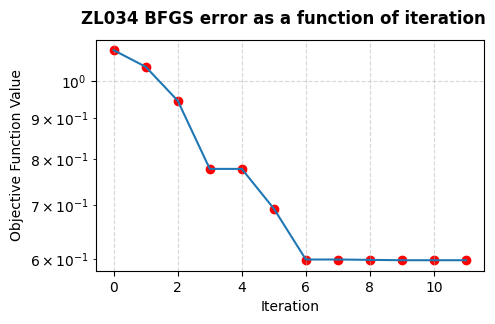

In [26]:
zl034_data = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)
zl034_obj, zl034_jac = gen_obj_jac_rot(zl034_data)
x0 = [0.5, 0.5, 0.5, -0.5, 0, 0, 0, 0]
res_zl034 = minimize(zl034_obj, x0, method="BFGS", jac=zl034_jac, options={"return_all":True, "gtol":1e-20, "xrtol":1e-20})

print(f"Final function:{res_zl034.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res_zl034.jac):.6f}")
print(f"alpha:{res_zl034.x[:4]}")
print(f"beta:{res_zl034.x[4:]}")

# plot the error as a function of iteration
errs = [zl034_obj(x) for x in res_zl034.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(5,3))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 BFGS error as a function of iteration", 
             fontsize=12, fontweight="bold");

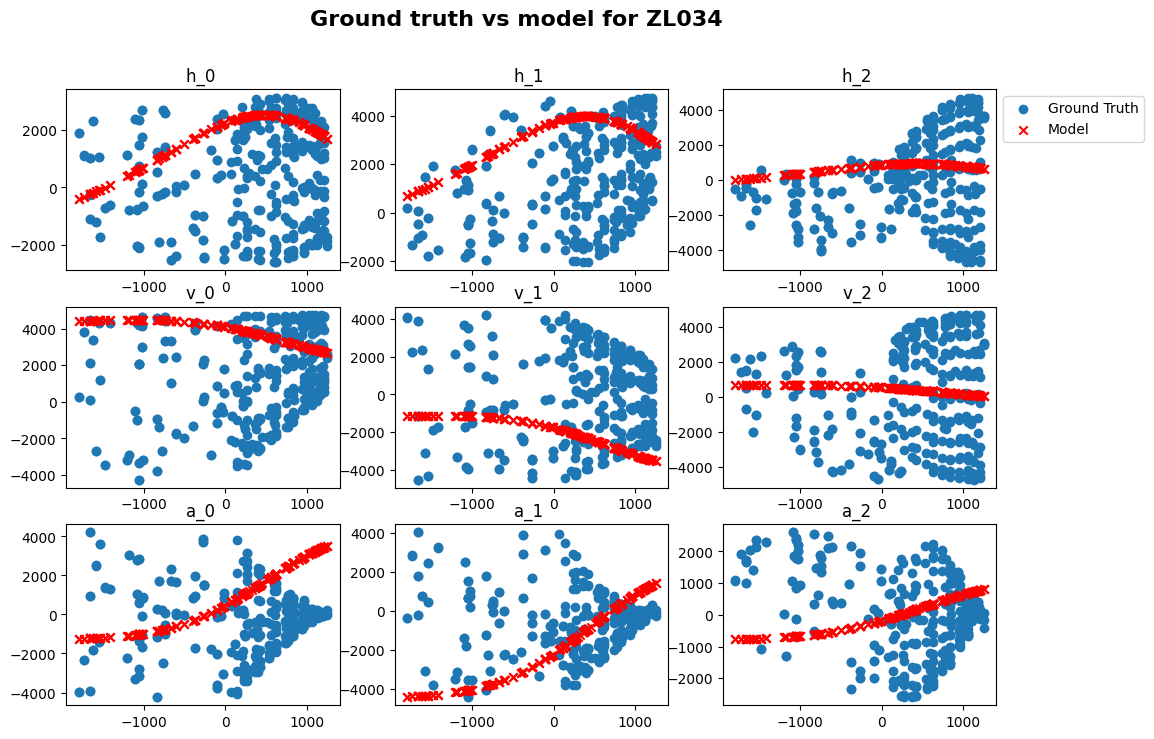

In [28]:
fmc = zl034_data["fmc"]
data_m = {"h0_prime":[], "h1_prime":[], "h2_prime":[],
        "v0_prime":[], "v1_prime":[], "v2_prime":[],
        "a0_prime":[], "a1_prime":[], "a2_prime":[],
        "h0":[], "h1":[], "h2":[],
        "v0":[], "v1":[], "v2":[],
        "a0":[], "a1":[], "a2":[],}

# model
alpha0, alpha1, alpha2, alpha3 = res_zl034.x[:4]
beta0, beta1, beta2, beta3 = res_zl034.x[4:]

# calculate the h prime, v primve and a primve for each datapoint
for idx in range(zl034_data.shape[0]):
  x = res_zl034.x

  
  H_r_gt = get_H_r_gt(idx, zl034_data)
  R_rpm = get_R_rpm(idx, zl034_data)
  R_rrp = get_R_rrp(idx, zl034_data)
  Kc = get_KC(idx, zl034_data)
  R_mc = get_R_mc(alpha0, alpha1, alpha2, alpha3, beta0, beta1, beta2, beta3, idx, zl034_data)
  

  # transform to mast frame
  H_m_prime = R_mc @ Kc
  H_m_gt = R_rpm.T @ R_rrp.T @ H_r_gt

  # H_m_prime = Kc @ R_mc
  # H_m_gt = H_r_gt @ R_rpm @ R_rrp
  
  for c in range(3):
    for r, vec in enumerate(["h", "v", "a"]):
      data_m[f"{vec}{c}_prime"].append(H_m_prime[r, c])
      data_m[f"{vec}{c}"].append(H_m_gt[r, c])
  

# plot the h, v, a for the ground truth and the model
fig, ax = plt.subplots(3, 3, figsize=(12,8))
for r, vec_name in enumerate(["h", "v", "a"]):
  for c in range(3):
    ax[r,c].scatter(fmc, data_m[f"{vec_name}{c}"])
    ax[r,c].scatter(fmc, data_m[f"{vec_name}{c}_prime"], color="red", marker='x')
    ax[r,c].set_title(f"{vec_name}_{c} ")
    
ax[0,2].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))
fig.suptitle("Ground truth vs model for ZL034", fontsize=16, fontweight="bold");

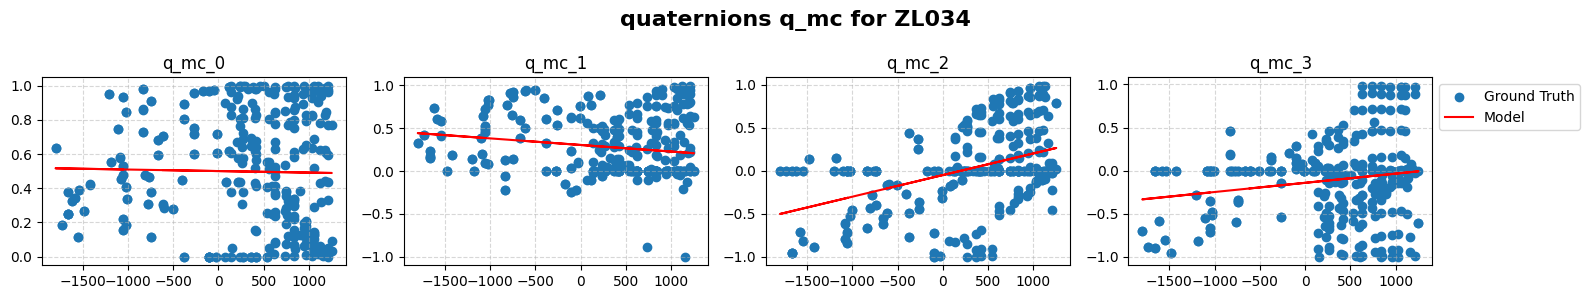

In [29]:
# plot the ground truth quaternions against the model quaternions as a function of fmc
alphas = res_zl034.x[:4]
betas = res_zl034.x[4:]

fig, ax = plt.subplots(1, 4, figsize=(16,3))
for c in range(4):
  ax[c].scatter(zl034_data["fmc"], zl034_data[f"q_mc_{c}"], label=f"q_mc_{c}")
  ax[c].plot(zl034_data["fmc"], alphas[c] + betas[c] * zl034_data["fmc"], color="red", label="model")
  ax[c].grid(linestyle="--", alpha=0.5)
  ax[c].set_title(f"q_mc_{c}")

ax[3].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))

fig.suptitle("quaternions q_mc for ZL034", fontsize=16, fontweight="bold")
plt.tight_layout();


### Right Camera Fitting

In [55]:
zr034_data = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)
zr034_obj, zr034_jac = gen_obj_jac_rot(zr034_data)
x0 = [0.5, 0.5, 0.5, -0.5, 0, 0, 0, 0]
res = minimize(zr034_obj, x0, method="BFGS", jac=zr034_jac, options={"return_all":True, "gtol":1e-20, "xrtol":1e-20})

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"alpha:{res.x[:4]}")
print(f"beta:{res.x[4:]}")

Final function:0.000029
Final Jacobian:0.000000
alpha:[ 0.46531296  0.45540531  0.54372635 -0.52952697]
beta:[ 5.79067707e-07  8.71683966e-07 -5.49416455e-06 -4.32881812e-06]


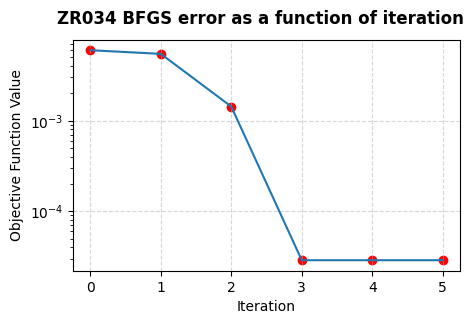

In [56]:
# plot the error as a function of iteration
errs = [zr034_obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(5,3))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZR034 BFGS error as a function of iteration", 
             fontsize=12, fontweight="bold");

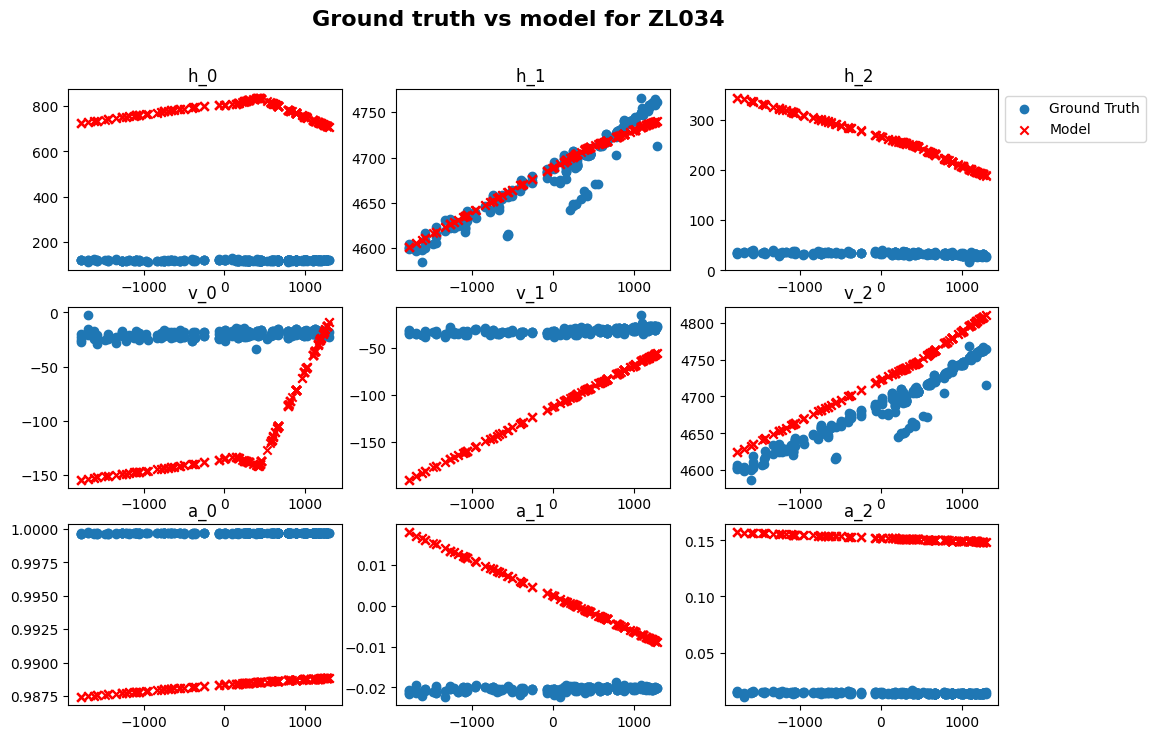

In [62]:
fmc = zr034_data["fmc"]
data_m = {"h0_prime":[], "h1_prime":[], "h2_prime":[],
        "v0_prime":[], "v1_prime":[], "v2_prime":[],
        "a0_prime":[], "a1_prime":[], "a2_prime":[],
        "h0":[], "h1":[], "h2":[],
        "v0":[], "v1":[], "v2":[],
        "a0":[], "a1":[], "a2":[],}

# model
alpha0, alpha1, alpha2, alpha3 = res.x[:4]
beta0, beta1, beta2, beta3 = res.x[4:]

# calculate the h prime, v primve and a primve for each datapoint
for idx in range(zr034_data.shape[0]):
  x = res.x
  R_rm = get_R_rm(idx, zr034_data)
  H_prime = get_H_prime(alpha0, alpha1, alpha2, alpha3,
                        beta0, beta1, beta2, beta3, idx, zr034_data)
  H_gt = get_H_gt(idx, zr034_data)

  # transform to mast frame
  H_m_prime = H_prime @ R_rm.T
  H_m_gt = H_gt @ R_rm

  
  data_m["h0_prime"].append(H_m_prime[0, 0])
  data_m["h1_prime"].append(H_m_prime[0, 1])
  data_m["h2_prime"].append(H_m_prime[0, 2])
  data_m["v0_prime"].append(H_m_prime[1, 0])
  data_m["v1_prime"].append(H_m_prime[1, 1])
  data_m["v2_prime"].append(H_m_prime[1, 2])
  data_m["a0_prime"].append(H_m_prime[2, 0])
  data_m["a1_prime"].append(H_m_prime[2, 1])
  data_m["a2_prime"].append(H_m_prime[2, 2])

  data_m["h0"].append(H_m_gt[0, 0])
  data_m["h1"].append(H_m_gt[0, 1])
  data_m["h2"].append(H_m_gt[0, 2])
  data_m["v0"].append(H_m_gt[1, 0])
  data_m["v1"].append(H_m_gt[1, 1])
  data_m["v2"].append(H_m_gt[1, 2])
  data_m["a0"].append(H_m_gt[2, 0])
  data_m["a1"].append(H_m_gt[2, 1])
  data_m["a2"].append(H_m_gt[2, 2])


# plot the h, v, a for the ground truth and the model
fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r, vec_name in enumerate(["h", "v", "a"]):
  for c in range(3):

    # plot the ground truth
    ax[r,c].scatter(fmc, data_m[f"{vec_name}{c}"])
    ax[r,c].scatter(fmc, data_m[f"{vec_name}{c}_prime"], color="red", marker='x')
    ax[r,c].set_title(f"{vec_name}_{c} ")
    
ax[0,2].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))
fig.suptitle("Ground truth vs model for ZL034", fontsize=16, fontweight="bold");

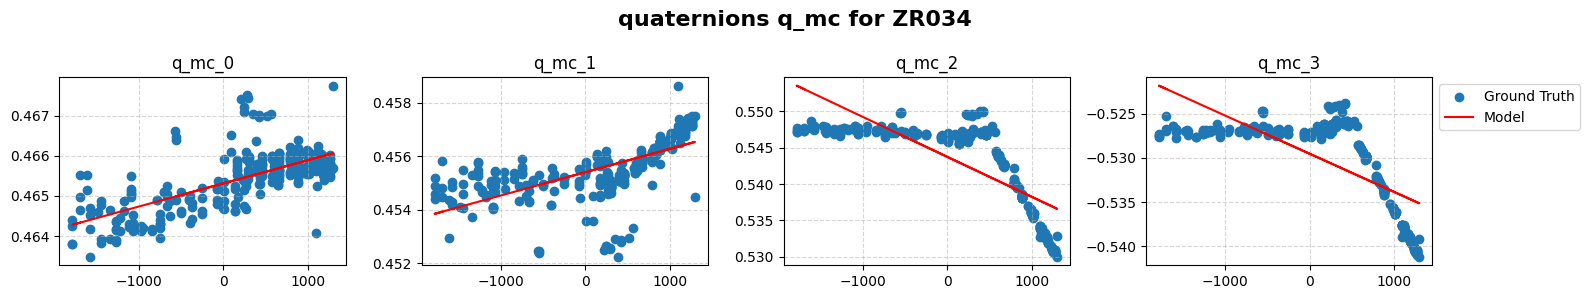

In [63]:
# plot the ground truth quaternions against the model quaternions as a function of fmc
alphas = res.x[:4]
betas = res.x[4:]

fig, ax = plt.subplots(1, 4, figsize=(16,3))

for c in range(4):

  ax[c].scatter(zr034_data["fmc"], zr034_data[f"q_mc_{c}"], label=f"q_mc_{c}")
  ax[c].plot(zr034_data["fmc"], alphas[c] + betas[c] * zr034_data["fmc"], color="red", label="model")

  ax[c].grid(linestyle="--", alpha=0.5)
  ax[c].set_title(f"q_mc_{c}")

ax[3].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))

fig.suptitle("quaternions q_mc for ZR034", fontsize=16, fontweight="bold")
plt.tight_layout();

## Camera Model Fitting

Here we want to fit the camera vector in the mast frame, $c^M$. Here we know the camera vector in the rover frame $c^r$, and they are related by 

 
 \begin{align}
  \begin{bmatrix} c^r \\ 1 \end{bmatrix} 
  &= T^r_{r'} T^{r'}_{m} \begin{bmatrix} c^m \\ 1 \end{bmatrix}\\
  
  &= \begin{bmatrix} R^r_{r'} & t^r_{r'}\\ 0 & 1/s_{r'}^r \end{bmatrix}
  \begin{bmatrix} R^{r'}_m & t^{r'}_m\\ 0 & 1 \end{bmatrix}
  \begin{bmatrix} c^m \\ 1 \end{bmatrix}\\

  &= \begin{bmatrix} (R^r_{r'}R^{r'}_mc^m + R^r_{r'}t_m^{r'}+t_{r'}^r) \\ 1/s_{r'}^r\end{bmatrix}
  \end{align}

Normalizing and comparing the non-homogeneous components,

$$R^r_{r'}R_m^{r'}c^m = \frac{1}{s^r_{r'}} c^r - t^r_{r'} - R_{r'}^rt_m^{r'}$$

Now becuase the rotation matrices $R^r_{r'}$,$R_m^{r'}$ are orthogonal, then their inverse are their transpose, so 
$$c^m = (R^r_{r'})^T(R_m^{r'})^T\left(\frac{1}{s^r_{r'}} c^r - t^r_{r'} - R_{r'}^rt_m^{r'}\right)$$

We let this above value derived from the datat be the ground truth. 

Now, we want to model the camera vector in the mast frame as a function of focus motor count, $f$, as the following 

  $$ (c^m)' = \alpha + \beta \cdot f 
  = \begin{bmatrix} \alpha_0 \\ \alpha_1 \\ \alpha_2 \end{bmatrix} + f \cdot \begin{bmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \end{bmatrix}
  = \begin{bmatrix} \alpha_0 + \beta_0f \\ \alpha_1 + \beta_1f \\ \alpha_2 + \beta_2f \end{bmatrix} $$

and we want to find $\alpha$ and $\beta$ that solves

  $$ \min_{\alpha,\beta} \sum_i \|(c^m)'_i - c^m_i\|^2_2 = \phi(\alpha, \beta)$$

where $\phi$ is the objective function and the jacobian function is 

  $$ \triangledown \phi = \sum_i
  \begin{bmatrix}
    2(\alpha_0 + \beta_0 f_i - c_{0,i})\\
    2(\alpha_1 + \beta_1 f_i - c_{1,i})\\
    2(\alpha_2 + \beta_2 f_i - c_{2,i})\\
    2(\alpha_0 + \beta_0 f_i - c_{0,i})f_i\\
    2(\alpha_1 + \beta_1 f_i - c_{1,i})f_i\\
    2(\alpha_2 + \beta_2 f_i - c_{2,i})f_i\\
  \end{bmatrix} $$

In [68]:
data_path = "data/m41_site_cal_v227_v8.xlsx"


data = pd.read_excel(data_path)
print(f"Number of data points:{data.shape[0]}")

# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# convert strings to vecs/mats
data["R_rpm_mat"] = [to_mat(m) for m in data["R_rpm"]]
data["t_rpm_vec"] = [to_vec_comma(t) for t in data["t_rpm"]]
data["c_r_vec"] = [to_vec_comma(c) for c in data["c_r"]]

Number of data points:3529


In [ ]:
# precompute the camera vectors from data
q_rrp = np.array([0.00035132, -0.0004781 ,  0.00048555, -0.99999971])
R_rrp = R.from_quat(q_rrp).as_matrix()
t_rrp = np.array([0.0007, 0.003, 0.0006])
s_rrp = 0.998

data["c_m"] = [None]*data.shape[0]
for idx in range(data.shape[0]):
  R_rpm = data["R_rpm_mat"][idx]
  t_rpm = data["t_rpm_vec"][idx]
  c_r = data["c_r_vec"][idx]
  data["c_m"][idx] = R_rpm.T @ R_rrp.T @ ((1/s_rrp)*c_r - t_rrp - R_rrp @ t_rpm)

x_mean:0.031314, y_mean:-0.124092, z_mean:-0.068550


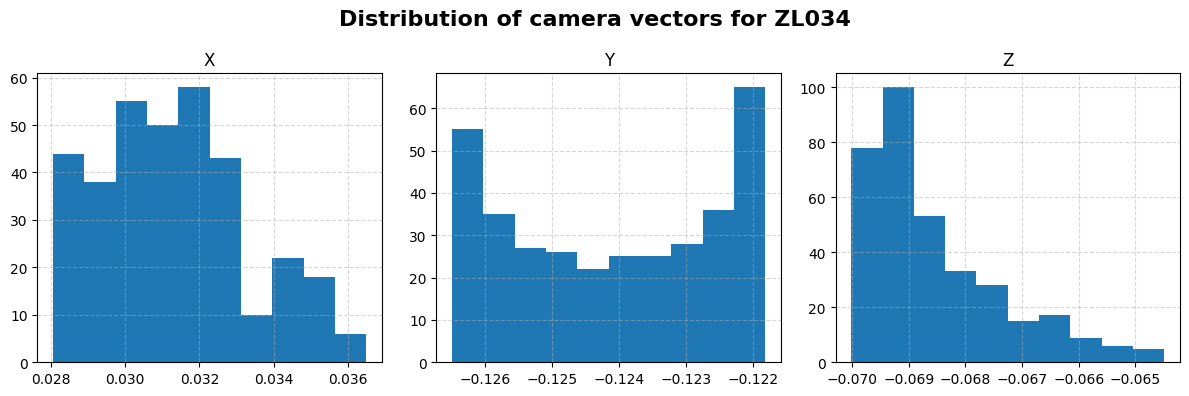

In [70]:
zl034_data = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

# plot the distribution of the camera vectors
fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].hist(zl034_data["c_m"].apply(lambda x: x[0]))
ax[0].set_title("X")
ax[0].grid(linestyle="--", alpha=0.5)

ax[1].hist(zl034_data["c_m"].apply(lambda x: x[1]))
ax[1].set_title("Y")
ax[1].grid(linestyle="--", alpha=0.5)

ax[2].hist(zl034_data["c_m"].apply(lambda x: x[2]))
ax[2].set_title("Z")
ax[2].grid(linestyle="--", alpha=0.5)

plt.suptitle("Distribution of camera vectors for ZL034", fontsize=16, fontweight="bold")
plt.tight_layout()

x_mean = zl034_data["c_m"].apply(lambda x: x[0]).mean()
y_mean = zl034_data["c_m"].apply(lambda x: x[1]).mean()
z_mean = zl034_data["c_m"].apply(lambda x: x[2]).mean()
print(f"x_mean:{x_mean:.6f}, y_mean:{y_mean:.6f}, z_mean:{z_mean:.6f}")

In [71]:
# objective and jacobian function for camera model
def gen_obj_jac_cam(_data):

  def obj(x):
    a0, a1, a2, b0, b1, b2 = x
    res = 0
    for idx in range(_data.shape[0]):
      f = _data["fmc"][idx]
      c = _data["c_m"][idx]
      res += (a0 + b0 * f - c[0])**2 + (a1 + b1 * f - c[1])**2 + (a2 + b2 * f - c[2])**2
    
    return res

  def jac(x):
    a0, a1, a2, b0, b1, b2 = x
    j = np.ones(6)

    for idx in range(_data.shape[0]):
      f = _data["fmc"][idx]
      c = _data["c_m"][idx]

      j += np.array([2*(a0+b0*f-c[0]),
                      2*(a1+b1*f-c[1]),
                      2*(a2+b2*f-c[2]),
                      2*(a0+b0*f-c[0])*f,
                      2*(a1+b1*f-c[1])*f,
                      2*(a2+b2*f-c[2])*f])
    return j/_data.shape[0]

  return obj, jac

In [74]:
zl034_data = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)
zl034_obj, zl034_jac = gen_obj_jac_cam(zl034_data)
x0 = [1, -1, -1, 0, 0, 0]
res = minimize(zl034_obj, x0, method="BFGS", jac=zl034_jac, options={"return_all":True, "gtol":1e-20, "xrtol":1e-20})

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"alpha:{res.x[:3]}")
print(f"beta:{res.x[3:]}")

Final function:0.004158
Final Jacobian:0.000001
alpha:[ 0.03008735 -0.12548533 -0.06991798]
beta:[-1.10891505e-06 -2.94247468e-07 -4.19201638e-07]


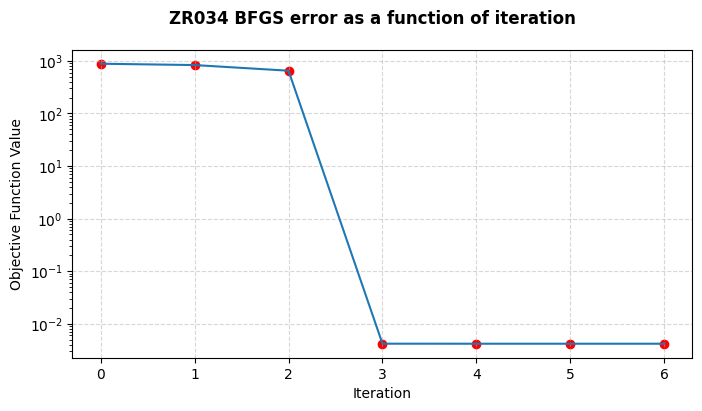

In [73]:
# plot the error as a function of iteration
errs = [zl034_obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

In [76]:
zr034_data = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)
zr034_obj, zr034_jac = gen_obj_jac_cam(zr034_data)
x0 = [1, -1, -1, 0, 0, 0]
res = minimize(zr034_obj, x0, method="BFGS", jac=zr034_jac, options={"return_all":True, "gtol":1e-20, "xrtol":1e-20})

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"alpha:{res.x[:3]}")
print(f"beta:{res.x[3:]}")

Final function:0.004426
Final Jacobian:0.001690
alpha:[ 0.03202635  0.11830591 -0.07033048]
beta:[ 1.09500225e-06 -2.71687146e-09 -8.08768353e-08]


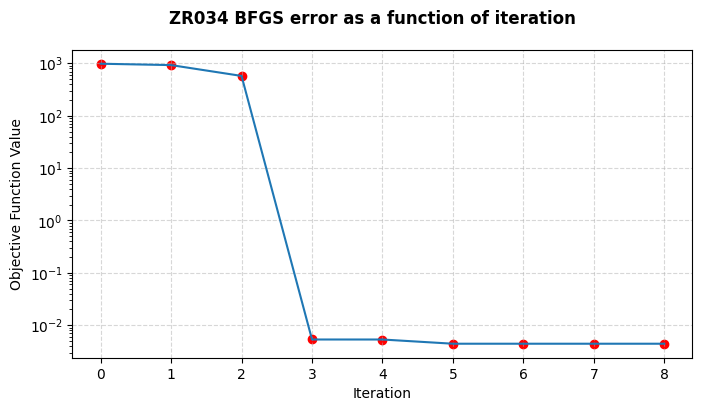

In [77]:
# plot the error as a function of iteration
errs = [zr034_obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

# Geocalibration V2.0 (06/28/2024)

## Rotation 

\begin{equation}
 R^r_c  = R^r_{r'} R^{r'}_mR_c^m  =   H^r(K^c)^{-1}
\end{equation}

We need to find $q^r_{r'}$, $\alpha_{c,z}^m$ and $\beta_{c,z}^m$ that solves 
\begin{align*}
    \min_{q^r_{r'}, \alpha^m_{c,z}, \beta_{c,z}^m} \sum_{z, i\in I_z} d\left(q^r_{c, z, i}, q^r_{r'} \otimes q^{r'}_{m,i} \otimes q^m_{c,z}(focus_i)\right)
    = \min_{q^r_{r'}, \alpha^m_{c,z}, \beta_{c,z}^m} \phi(q^r_{r'}, \alpha^m_{c,z}, \beta_{c,z}^m)
\end{align*}
where $I_z$ is the set of data indices that correspond to the camera $z$. 

To find the Jacobian of the objective function, let $q_{i,z}=q^r_{r'} \otimes q^{r'}_{m,i} \otimes q^m_{c,z}(focus_i)$ and let $t_i=\langle q^r_{c,z,i}, q_{i,z}\rangle$, 
\begin{align}
    \frac{\partial \phi}{\partial t_i} = 
    -\frac{4t_i}{\sqrt{2-2t_i^2}} 
\end{align}
Now, 
\begin{align*}
    \frac{\partial t_i}{\partial q^{r'}_r} = (q_c^r)^T \cdot \frac{\partial q_{i,z}}{\partial q^r_{r'}}, 
    \frac{\partial t_i}{\partial \alpha^{m}_{c,z}} =  (q_c^r)^T \frac{\partial q_{i,z}}{\partial \alpha^m_{c,z}} , 
    \frac{\partial t_i}{\partial \beta^{m}_{c,z}} = (q_c^r)^T \frac{\partial q_{i,z}}{\partial \beta^m_{c,z}} 
\end{align*}

where
\begin{align*}
    \frac{\partial q_{i,z}}{\partial q^r_{r'}} &=& \begin{bmatrix}
        (q^{r'}_m \otimes q^m_c)_0 
        & -(q^{r'}_m \otimes q^m_c)^T_{Im}\\
        (q^{r'}_m \otimes q^m_c)_{Im}
        & (q^{r'}_m \otimes q^m_c)_0 I_3 - \left[ q^{r'}_m \otimes q^m_c \right]_\times
    \end{bmatrix}\\
    \frac{\partial q_{i,z}}{\partial \alpha^m_{c,z}} &= &\begin{bmatrix}
        (q^r_{r'} \otimes q^{r'}_m)_0 
        & -(q_{r'}^r \otimes q^{r'}_m)^T_{Im}\\
        (q_{r'}^r \otimes q^{r'}_m)_{Im} 
        &  (q_{r'}^r \otimes q^{r'}_m)_0 I_3 - \left[ (q^r_{r'} \otimes q^{r'}_m) \right]_\times
    \end{bmatrix}\\
    \frac{\partial q_{i,z}}{\partial \beta^m_{c,z}} &= f &\begin{bmatrix}
        (q^r_{r'} \otimes q^{r'}_m)_0 
        & -(q_{r'}^r \otimes q^{r'}_m)^T_{Im}\\
        (q_{r'}^r \otimes q^{r'}_m)_{Im} 
        &  (q_{r'}^r \otimes q^{r'}_m)_0 I_3 - \left[ (q^r_{r'} \otimes q^{r'}_m) \right]_\times
    \end{bmatrix}
\end{align*}

So the Jacobian is 

\begin{align*}
    \triangledown \phi = \sum_{z, i\in I_z}  
    \frac{4t_i}{\sqrt{2-2t^2}}
    \begin{bmatrix}
        \left(\frac{\partial q_{i,z}}{\partial q^r_{r'}}\right)^T q^r_c\\
        \left(\frac{\partial q_{i,z}}{\partial \alpha^m_{c,ZL034}}\right)^T q^r_c\\
        \left(\frac{\partial q_{i,z}}{\partial \beta^m_{c,ZL034}}\right)^T q^r_c\\
        \left(\frac{\partial q_{i,z}}{\partial \alpha^m_{c,ZR034}}\right)^T q^r_c\\
        \left(\frac{\partial q_{i,z}}{\partial \beta^m_{c,ZR034}}\right)^T q^r_c
    \end{bmatrix}
\end{align*}
Note that $\frac{\partial q_{i,z}}{\partial \alpha^m_{c,z}}$ and $\frac{\partial q_{i,z}}{\partial \beta^m_{c,z}}$ will be zero if the camera $z$ does not match the camera type of datapoint $i$.   

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
pd.options.mode.chained_assignment = None  # default='warn'

In [9]:
data_fpath = "data/m41_site_cal_v227_v8_processed.xlsx"
data = pd.read_excel(data_fpath)

# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# convert strings to vecs/mats
# data["h_r_vec" ] = [to_vec_space(v) for v in data["h_r_est"]]
# data["v_r_vec" ] = [to_vec_space(v) for v in data["v_r_est"]]
# data["a_r_vec" ] = [to_vec_space(v) for v in data["a_r_est"]]
data["h_r_vec" ] = [to_vec_comma(v) for v in data["h_r"]]
data["v_r_vec" ] = [to_vec_comma(v) for v in data["v_r"]]
data["a_r_vec" ] = [to_vec_comma(v) for v in data["a_r"]]
data["R_rpm_mat"] = [to_mat(m) for m in data["R_rpm"]]


zl34 = data[data["cam"] == "ZL034"].copy()
zl34.reset_index(drop=True, inplace=True)
zr34 = data[data["cam"] == "ZR034"].copy()
zr34.reset_index(drop=True, inplace=True)

print(f"Number of data points for zl034:{zl34.shape[0]}")
print(f"Number of data points for zr034:{zr34.shape[0]}")

Number of data points for zl034:344
Number of data points for zr034:323


In [107]:
left_fl = {"alpha": 4684.257100, "beta": 0.0497613}
right_fl = {"alpha": 4689.772199, "beta": 0.053044}


def get_fl(idx:int, data_:np.ndarray)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl["beta"] * fmc + left_fl["alpha"]
  else:
    return right_fl["beta"] * fmc + right_fl["alpha"]

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1"][idx], data_["b2"][idx], data_["cx"][idx], data_["cy"][idx]
  fl = get_fl(idx, data_)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray)->np.ndarray:
  b1, b2, cx, cy = data_["b1"][idx], data_["b2"][idx], data_["cx"][idx], data_["cy"][idx]
  fl = get_fl(idx, data_)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=0)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=0)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=0)
  H_i = np.concatenate([h_i, v_i, a_i], axis=0)

  return H_i

def get_q_rc_data(idx:int, data_: np.ndarray)->np.ndarray:
  """
  Forms the quaternion that corresponds to a rotation from r to c from data
  """
  H_r = get_H_r_data(idx, data_)
  K_c_inv = get_KC_inv(idx, data_)
  return R.from_matrix(H_r @ K_c_inv.T).as_quat()

def get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                  q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3,
                  q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3, 
                  idx:int, data_:np.ndarray):
  """
  Forms the quaternion that corresponds to a rotation from r to c from model
  """
  rot_rrp = R.from_quat(np.array([q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3]))

  rot_rpm = R.from_matrix(get_R_rpm(idx, data_))

  rot_mc = R.from_quat(np.array([q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3]) + \
    np.array([q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3]) * data_["fmc"][idx])
  
  return (rot_rrp * rot_rpm * rot_mc).as_quat()


In [108]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

data034 = pd.concat([zl34, zr34], axis=0)
data034.reset_index(drop=True, inplace=True)

# objective function for the model
def obj(x)->float:
  
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
    
    elif data034["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
  
  return total_dist/count



In [109]:
x0 = [0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,]
res = minimize(obj, x0, method="BFGS", options={"return_all":True})

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{res.x[:4]/np.linalg.norm(res.x[:4])}")
print(f"q_cm_zl_a:{res.x[4:8]/np.linalg.norm(res.x[4:8])}")
print(f"q_cm_zl_b:{res.x[8:12]/np.linalg.norm(res.x[8:12])}")
print(f"q_cm_zr_a:{res.x[12:16]/np.linalg.norm(res.x[12:16])}")
print(f"q_cm_zr_b:{res.x[16:20]/np.linalg.norm(res.x[16:20])}")

Final function:1.210793
Final Jacobian:0.000070
q_rrp:[ 0.26332161  0.50175505  0.65883411 -0.49481432]
q_cm_zl_a:[ 0.4223811   0.57916363  0.56597255 -0.40723307]
q_cm_zl_b:[-0.74180667 -0.07660895  0.06207728 -0.66332521]
q_cm_zr_a:[ 0.53156673  0.57646525  0.55588561 -0.27589095]
q_cm_zr_b:[-0.74202364 -0.03442915  0.04248362 -0.66813972]


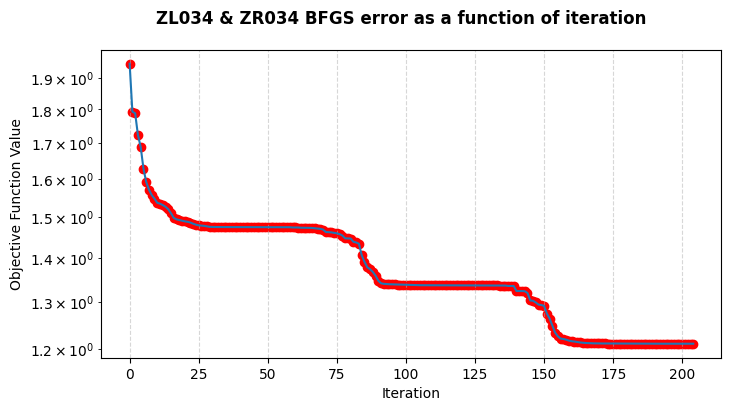

In [110]:
# plot the error as a function of iteration
errs = [obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

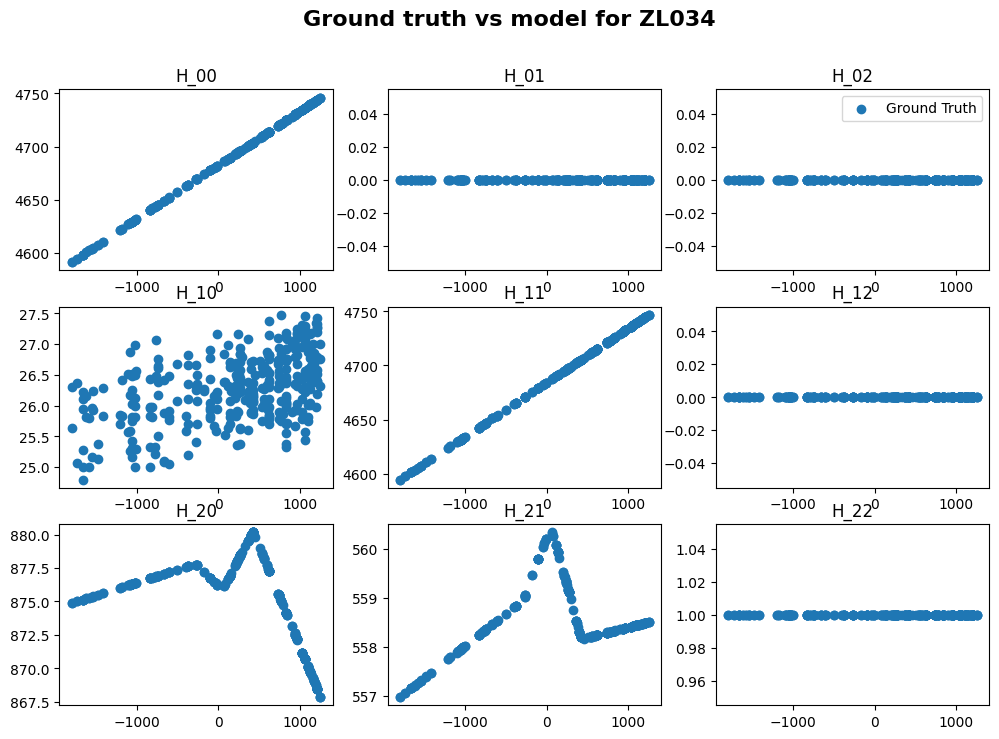

In [120]:
# See how well the above fit is

q_rrp = np.array([-0.0117128, -0.03611363, 0.99662084, 0.07283904])

q_cm_zl_a = np.array([ 0.73336009, 0.61516565, 0.00452326, -0.28936781])
q_cm_zl_b = np.array([-0.61863097, 0.70370086, 0.23616955, -0.25753597])

q_cm_zr_a = np.array([-0.78276713, -0.56807478, 0.02929144, 0.25240577])
q_cm_zr_b = np.array([-0.59928184, 0.72852352, 0.21826227, -0.24995268])


# Compute H_r from model
H_c_model = []
H_c_gt = []

zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zl034.shape[0]):
  # compute the rotation R_rc
  f = zl034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl034))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zl034)
  H_c_model.append(R_rc.T @ H_r)

  H_c_gt.append(get_KC(i, zl034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    # ax[r,c].scatter(zl034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"H_{r}{c}")

ax[0,2].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))

fig.suptitle("Ground truth vs model for ZL034", fontsize=16, fontweight="bold");

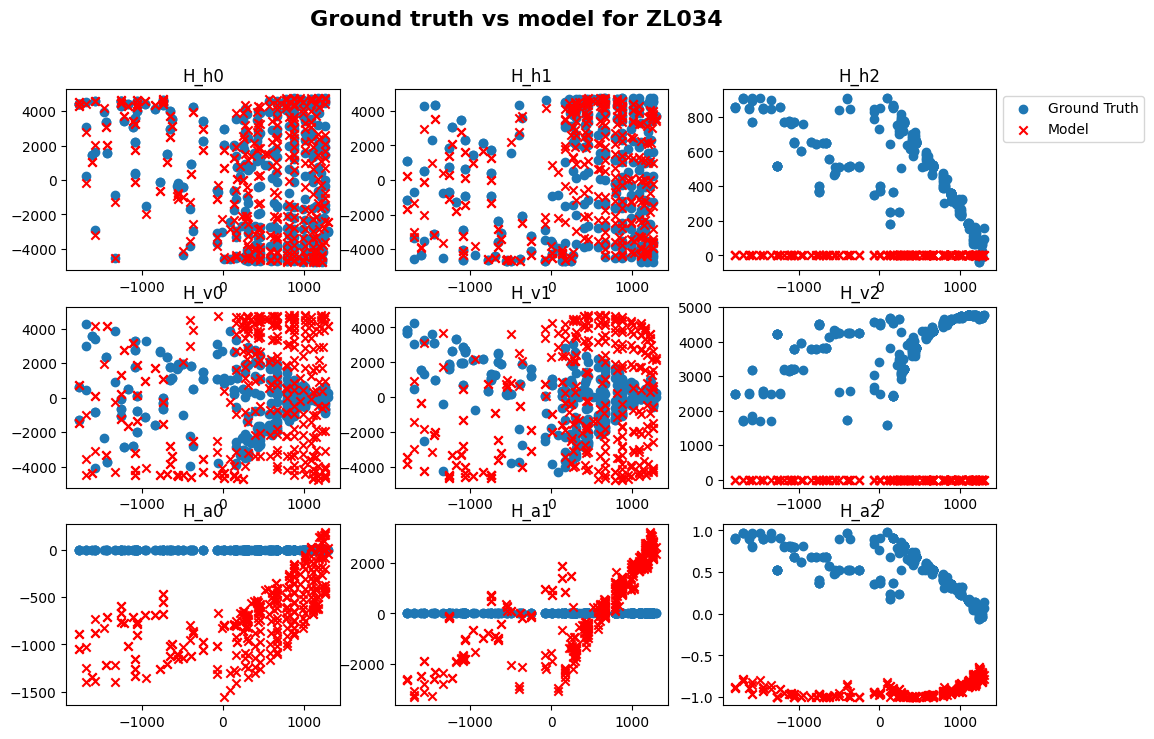

In [118]:
# Compute H_r from model
H_r_models = []
H

zr034 = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zr034.shape[0]):
  f = zr034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zr034))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)

  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  H_r_models.append(R_rc @ get_KC(i, zr034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r,vec_name in enumerate(["h", "v", "a"]):
  for c in range(3):

    ax[r,c].scatter(zr034["fmc"], [v [c] for v in zr034[f"{vec_name}_r_vec"]], label="data")
    ax[r,c].scatter(zr034["fmc"], [H[r, c] for H in H_r_models], color="red", marker='x', label="model")
    ax[r,c].set_title(f"H_{vec_name}{c}")

ax[0,2].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))

fig.suptitle("Ground truth vs model for ZL034", fontsize=16, fontweight="bold");

In [41]:
# Minimization with equality constraints
q_rrp_constr = {'type': 'eq',
                'fun': lambda x: x[0]**2 + x[1]**2 + x[2]**2 + x[3]**2 - 1,
                'jac': lambda x: np.concatenate([2*x[:4], np.zeros(16)])}

q_mc_zl_a_constr = {'type': 'eq',
                'fun': lambda x: x[4]**2 + x[5]**2 + x[6]**2 + x[7]**2 - 1,
                'jac': lambda x: np.concatenate([np.zeros(4), 2*x[4:8], np.zeros(12)])}

q_mc_zr_a_constr = {'type': 'eq',
                'fun': lambda x: x[12]**2 + x[13]**2 + x[14]**2 + x[15]**2 - 1,
                'jac': lambda x: np.concatenate([np.zeros(12), 2*x[12:16], np.zeros(4)])}

x0 = [0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,]

res = minimize(obj, x0, method="SLSQP",
               constraints=[q_rrp_constr, q_mc_zl_a_constr, q_mc_zr_a_constr],
               options={"disp":True})


Iteration limit reached    (Exit mode 9)
            Current function value: 1.043527985009256
            Iterations: 100
            Function evaluations: 2130
            Gradient evaluations: 100


In [42]:
print(f"q_rrp:{res.x[:4]/np.linalg.norm(res.x[:4])}")
print(f"q_cm_zl_a:{res.x[4:8]/np.linalg.norm(res.x[4:8])}")
print(f"q_cm_zl_b:{res.x[8:12]/np.linalg.norm(res.x[8:12])}")
print(f"q_cm_zr_a:{res.x[12:16]/np.linalg.norm(res.x[12:16])}")
print(f"q_cm_zr_b:{res.x[16:20]/np.linalg.norm(res.x[16:20])}")

q_rrp:[-0.0124353  -0.03890558  0.99677886  0.06901898]
q_cm_zl_a:[-0.27479393  0.87296434  0.2280092  -0.33231517]
q_cm_zl_b:[-0.61561371  0.70505495  0.23570779 -0.26145576]
q_cm_zr_a:[-0.77240041 -0.57321034 -0.04382691  0.27001245]
q_cm_zr_b:[-0.59984497  0.72755258  0.22012853 -0.24979328]


In [111]:
# Jacobian function

def get_t(q_rrp_0:float, q_rrp_1:float, q_rrp_2:float, q_rrp_3:float,
          q_mc_a0:float, q_mc_a1:float, q_mc_a2:float, q_mc_a3:float,
          q_mc_b0:float, q_mc_b1:float, q_mc_b2:float, q_mc_b3:float,
          idx:int, data_:np.ndarray):
  """
  Inner product between the q_rc_data and q_rc_model
  """

  q_rc_data = get_q_rc_data(idx, data_)
  q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                              q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3,
                              q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3,
                              idx, data_)
  return np.dot(q_rc_data, q_rc_model)

def cross_mat(q:np.ndarray)->np.ndarray:
  """
  Returns the cross product matrix
  """
  return np.array([[0, -q[3], q[2]],
                   [q[3], 0, -q[1]],
                   [-q[2], q[1], 0]])

def get_dq_dq_rrp(q_rrp_0:float, q_rrp_1:float, q_rrp_2:float, q_rrp_3:float,
                  q_mc_a0:float, q_mc_a1:float, q_mc_a2:float, q_mc_a3:float,
                  q_mc_b0:float, q_mc_b1:float, q_mc_b2:float, q_mc_b3:float,
                  idx:int, data_:np.ndarray)->np.ndarray:
  """
  Returns the matrix dq/dq_rrp
  """
  rot_rpm =  R.from_matrix(get_R_rpm(idx, data_))
  rot_mc = R.from_quat(np.array([q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3]) + \
    np.array([q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3]) * data_["fmc"][idx])
  
  # find quaternion q_rpc
  rot_rpc = rot_rpm * rot_mc
  q_rpc = rot_rpc.as_quat()

  first_row = np.expand_dims(np.array([q_rpc[0], -q_rpc[1], -q_rpc[2], -q_rpc[3]]), axis=0)
  q_rpc_im_vec = np.expand_dims(q_rpc[1:], axis=1)
  bottom_rows = np.concatenate([q_rpc_im_vec, q_rpc[0] * np.eye(3) - cross_mat(q_rpc)], axis=1)
  dq_dq_rrp = np.concatenate([first_row, bottom_rows], axis=0)

  return dq_dq_rrp

def get_dq_dq_mc_a(q_rrp_0:float, q_rrp_1:float, q_rrp_2:float, q_rrp_3:float,
                  q_mc_a0:float, q_mc_a1:float, q_mc_a2:float, q_mc_a3:float,
                  q_mc_b0:float, q_mc_b1:float, q_mc_b2:float, q_mc_b3:float,
                  idx:int, data_:np.ndarray)->np.ndarray:
  """
  Returns the matrix dq/dq_rrp
  """
  rot_rrp = R.from_quat(np.array([q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3]))
  rot_rpm = R.from_matrix(get_R_rpm(idx, data_))
  
  # find quaternion q_rpc
  rot_rm = rot_rrp * rot_rpm
  q_rm = rot_rm.as_quat()

  first_row = np.expand_dims(np.array([q_rm[0], -q_rm[1], -q_rm[2], -q_rm[3]]), axis=0)
  q_rm_im_vec = np.expand_dims(q_rm[1:], axis=1)
  bottom_rows = np.concatenate([q_rm_im_vec, q_rm[0] * np.eye(3) - cross_mat(q_rm)], axis=1)
  dq_dq_rrp = np.concatenate([first_row, bottom_rows], axis=0)

  return dq_dq_rrp

def get_dq_dq_mc_b(q_rrp_0:float, q_rrp_1:float, q_rrp_2:float, q_rrp_3:float,
                  q_mc_a0:float, q_mc_a1:float, q_mc_a2:float, q_mc_a3:float,
                  q_mc_b0:float, q_mc_b1:float, q_mc_b2:float, q_mc_b3:float,
                  idx:int, data_:np.ndarray)->np.ndarray:
  """
  Returns the matrix dq/dq_rrp
  """
  f = data_["fmc"][idx]
  rot_rrp = R.from_quat(np.array([q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3]))
  rot_rpm = R.from_matrix(get_R_rpm(idx, data_))
  
  # find quaternion q_rpc
  rot_rm = rot_rrp * rot_rpm
  q_rm = rot_rm.as_quat()

  first_row = np.expand_dims(np.array([q_rm[0], -q_rm[1], -q_rm[2], -q_rm[3]]), axis=0)
  q_rm_im_vec = np.expand_dims(q_rm[1:], axis=1)
  bottom_rows = np.concatenate([q_rm_im_vec, q_rm[0] * np.eye(3) - cross_mat(q_rm)], axis=1)
  dq_dq_rrp = np.concatenate([first_row, bottom_rows], axis=0)

  return f * dq_dq_rrp


In [112]:
def obj(x)->float:
  
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
    
    elif data034["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
  
  return total_dist/count

def jac(x:np.ndarray)->np.ndarray:
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

  j = np.zeros(20)
  count = 0
  for i in range(data034.shape[0]):
    if data034["cam"][i] == "ZL034":
      x_l = [q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
            q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
            q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3]
      
      q_rc_data = get_q_rc_data(i, data034)
      t = get_t(*x_l,i, data034)
      dq_dq_rrp = get_dq_dq_rrp(*x_l, i, data034)
      dq_dq_mca_l = get_dq_dq_mc_a(*x_l, i, data034)
      dq_dq_mcb_l = get_dq_dq_mc_b(*x_l, i, data034)

      j += (-4*t)/np.sqrt(2-2*t**2) * np.concatenate([dq_dq_rrp.T @ q_rc_data,
                        dq_dq_mca_l.T @ q_rc_data,
                        dq_dq_mcb_l.T @ q_rc_data,
                        np.zeros(8)])
      count += 1
      
    elif data034["cam"][i] == "ZR034":
      x_r = [q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
            q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
            q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3]
      
      q_rc_data = get_q_rc_data(i, data034)
      t = get_t(*x_r,i, data034)
      dq_dq_rrp = get_dq_dq_rrp(*x_r, i, data034)
      dq_dq_mca_r = get_dq_dq_mc_a(*x_r, i, data034)
      dq_dq_mcb_r = get_dq_dq_mc_b(*x_r, i, data034)

      j += (-4*t)/np.sqrt(2-2*t**2) * np.concatenate([dq_dq_rrp.T @ q_rc_data,
                        np.zeros(8),
                        dq_dq_mca_r.T @ q_rc_data,
                        dq_dq_mcb_r.T @ q_rc_data])
      count += 1
      
  return j/count

x0 = [0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5,]
res = minimize(obj, x0, method="BFGS", jac=jac, options={"return_all":True})

In [113]:
print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{res.x[:4]}")
print(f"q_cm_zl_a:{res.x[4:8]}")
print(f"q_cm_zl_b:{res.x[8:12]}")
print(f"q_cm_zr_a:{res.x[12:16]}")
print(f"q_cm_zr_b:{res.x[16:20]}")

Final function:1.944976
Final Jacobian:799.525006
q_rrp:[ 0.5  0.5  0.5 -0.5]
q_cm_zl_a:[ 0.5  0.5  0.5 -0.5]
q_cm_zl_b:[ 0.5  0.5  0.5 -0.5]
q_cm_zr_a:[ 0.5  0.5  0.5 -0.5]
q_cm_zr_b:[ 0.5  0.5  0.5 -0.5]


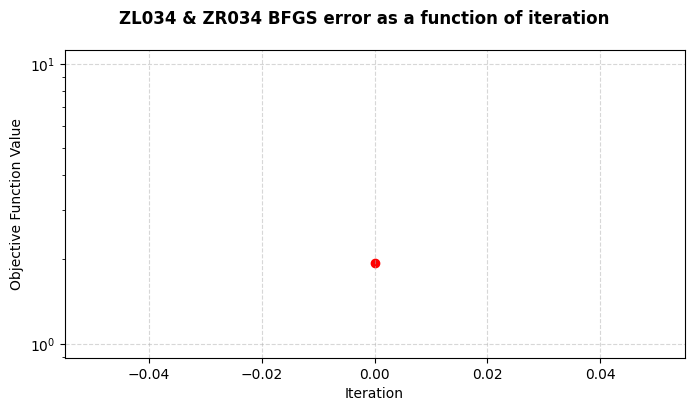

In [114]:
# plot the error as a function of iteration
errs = [obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

In [104]:
jac(x0)

array([ 1.21896124e+00, -1.06574345e+00, -1.61245358e+00,  7.56327685e-02,
        2.99638427e-01,  4.89029471e-01, -4.72787144e-01,  3.05843824e-01,
        2.26593311e+02,  3.60153851e+02, -3.42761566e+02,  2.68139746e+02,
        3.71382020e-01,  5.21816981e-01, -5.01842371e-01,  3.90113743e-01,
        2.16021488e+02,  3.42534196e+02, -3.50797108e+02,  2.83967078e+02])